In [144]:
import pandas as pd
import sys
import importlib

In [145]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [146]:
sys.path.append("../src")
import eda_utils as eda
import modeling as mod
import visualization as visual
import data_splitting as split
import preprocessing as prep

importlib.reload(eda)
importlib.reload(visual)
importlib.reload(prep)

<module 'preprocessing' from '/home/abril/UdeSA/ML/TP_Final_ML/notebooks/../src/preprocessing.py'>

In [147]:
X_train_pp = pd.read_csv("../data/X_train_pp.csv")
X_val_pp = pd.read_csv("../data/X_val_pp.csv")

# Datasests pre one-hot for cross validation
# X_train = pd.read_csv("../data/X_train.csv")
# X_val = pd.read_csv("../data/X_val.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_val = pd.read_csv("../data/y_val.csv").squeeze()

# Feature Engeneering

Para lograr capturar nuevas relacione sentre features, se realizan combinaciones li entre ellos. Vamos a combiar aquellos fearures con mayor correlacion con el target, juanto con featutres con correlscion entre sí y con el target. Además, se agregarán columnas ordinales para mejorar las carácteristicas del dataset

## Combining features

NO NOS CAMBIA EN NADA GUATAFAK

In [148]:
cols_to_drop = ["Con cámara de retroceso"]

X_train_pp_2 = X_train_pp.drop(columns=cols_to_drop, errors="ignore")
X_val_pp_2 = X_val_pp.drop(columns=cols_to_drop, errors="ignore")

In [149]:
xgboost_log_model, xgboost_log_metrics = mod.train_xgboost(
    X_train_pp_2,
    y_train,
    X_val_pp_2,
    y_val,
    use_log_target=True,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
)


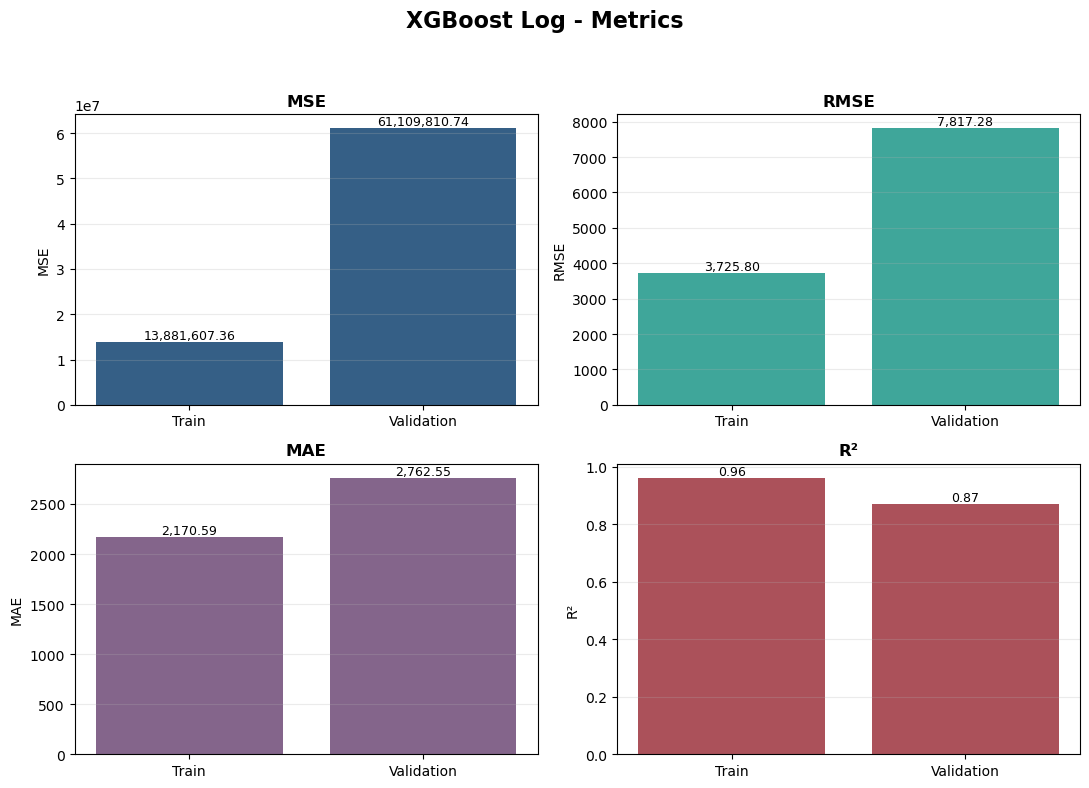

In [150]:
visual.plot_regression_metrics(
    xgboost_log_metrics,
    model_name="XGBoost Log",
)